# IT Helpdesk Ticket Analytics

Analysis of IT support tickets across a multi-site organization (corporate offices, data centers, remote branches, and a maritime/port site), examining ticket volume, SLA compliance, and resolution patterns — with a machine learning model to predict SLA breach risk.

## Step 1-3: Data Generation, Cleaning, and Exploratory Analysis

This section generates a realistic ticket dataset (with built-in real-world relationships between category, site, technician skill, and resolution time), cleans it (removing duplicates, handling missing values, fixing invalid entries), and explores it through 7 visualizations.

STEP 1 DONE: Generated 1224 rows
   ticket_id         date_raised              date_resolved         site_type  \
0  TCK-10150 2026-04-21 18:39:00                        NaT     Remote/Branch   
1  TCK-10427 2025-09-05 14:07:00 2025-09-06 10:43:00.000000  Corporate Office   
2  TCK-10544 2025-12-27 05:08:00 2025-12-30 14:39:48.000000     Remote/Branch   
3  TCK-10294 2026-02-15 02:09:00 2026-02-15 12:59:34.348858  Corporate Office   
4  TCK-10071 2025-04-17 04:16:00 2025-04-19 06:02:12.000000     Maritime/Port   
5  TCK-10529 2025-07-15 01:17:00 2025-07-15 03:06:12.000000  Corporate Office   
6  TCK-10613 2025-04-28 00:54:00                        NaT       Data Center   
7  TCK-10885 2025-04-14 08:41:00 2025-04-14 12:53:36.000000       Data Center   
8  TCK-10595 2026-07-13 05:43:00 2026-07-22 11:32:15.498858  Corporate Office   
9  TCK-11175 2026-08-28 08:03:00 2026-08-29 07:11:24.000000     Remote/Branch   

          category  priority assigned_technician  resolution_hours  \
0    

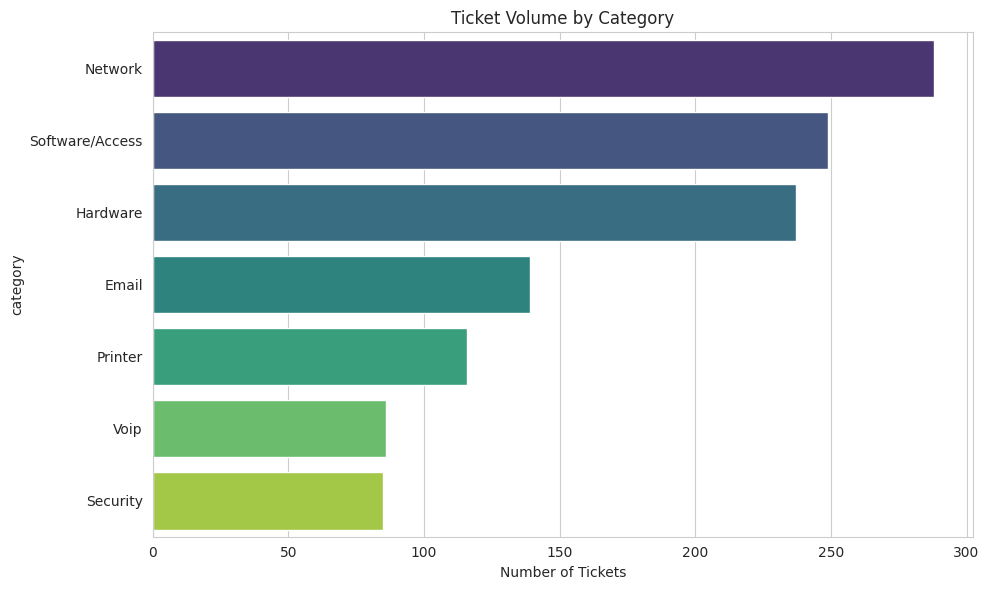

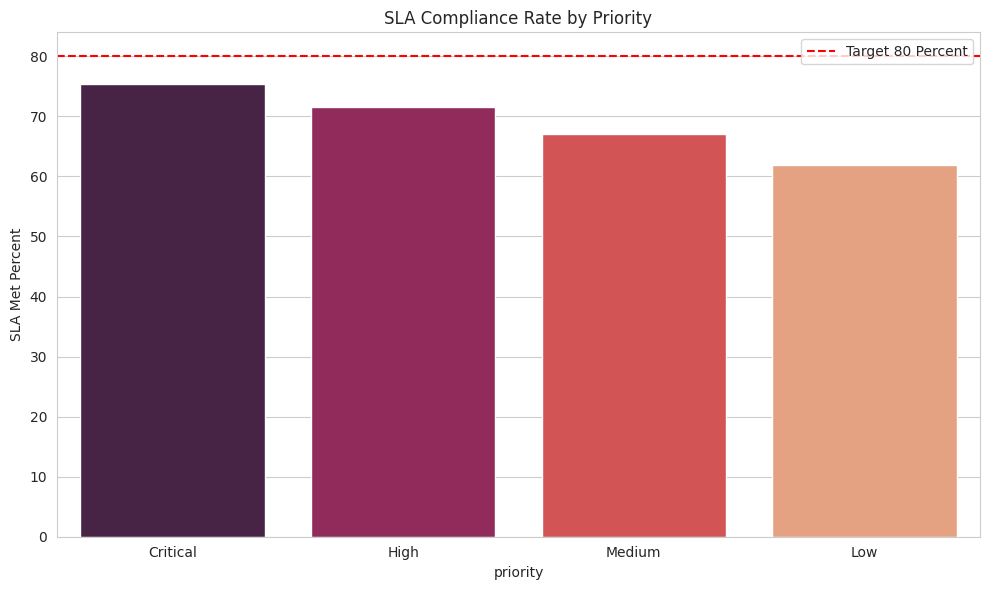

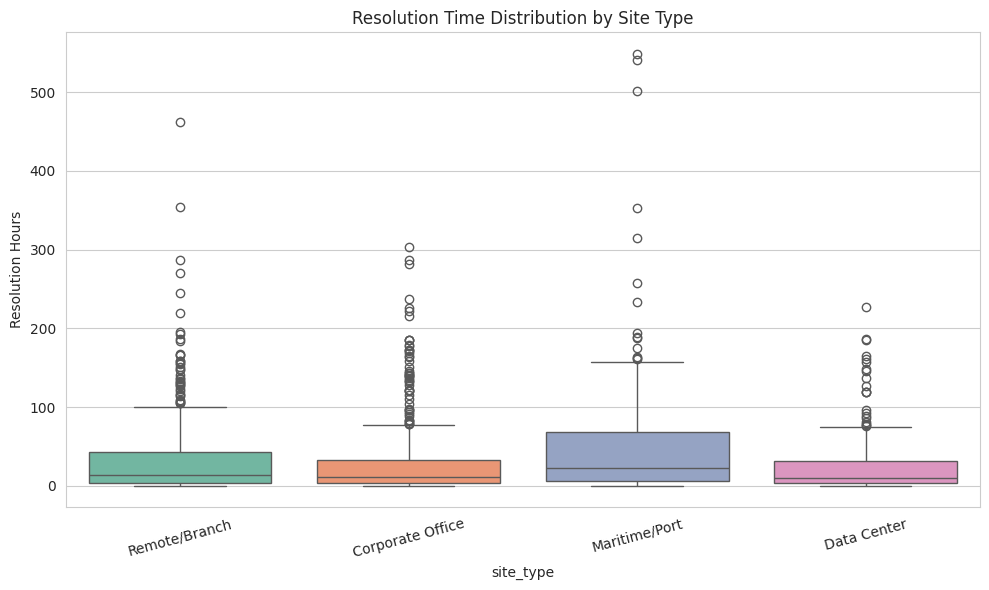

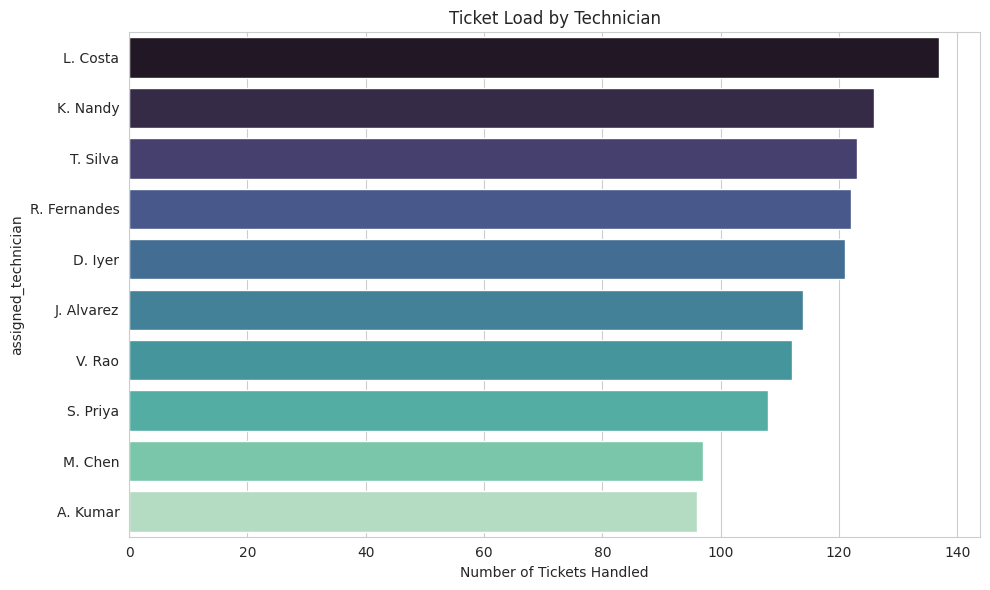

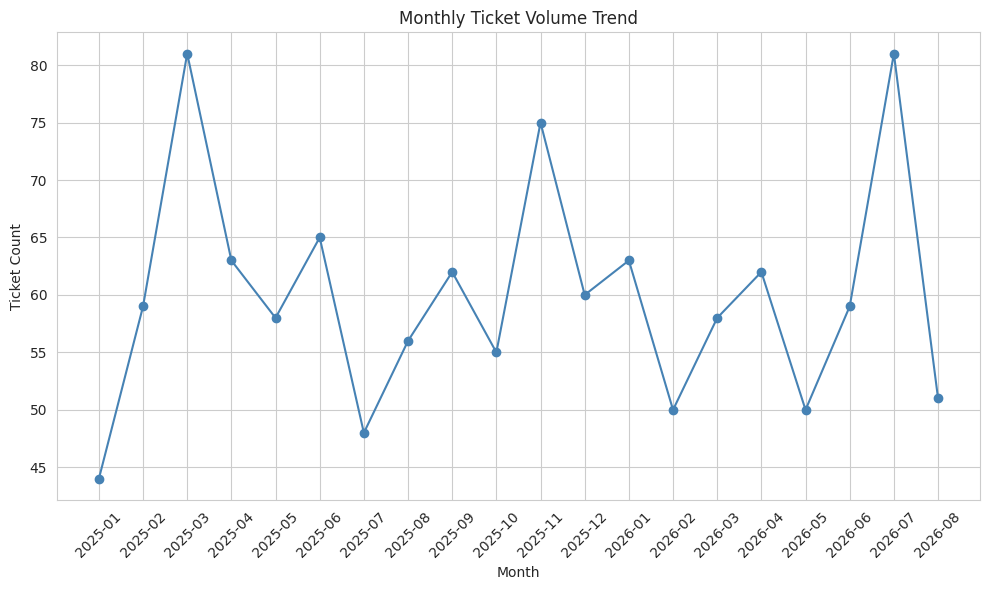

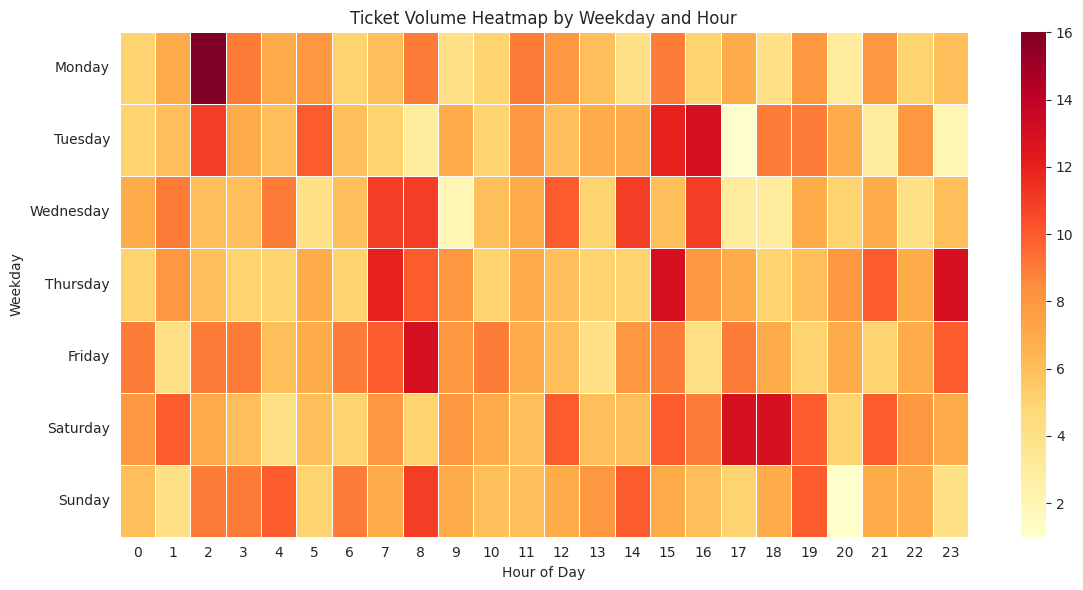

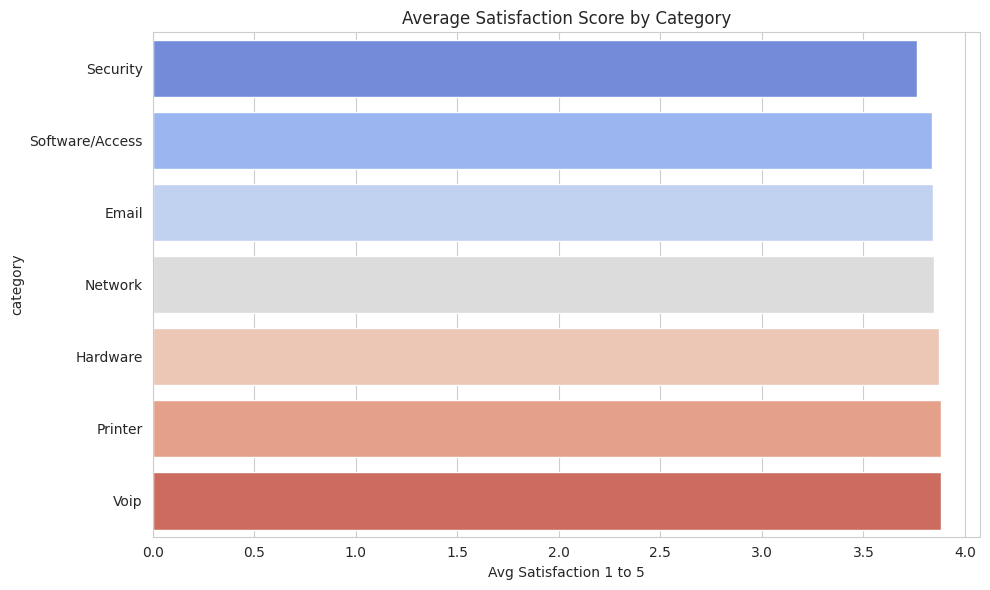

STEP 3 DONE: All 7 charts saved as PNG files.


In [1]:
# ==== ALL IMPORTS ====
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ==== STEP 1: GENERATE DATASET (WITH REAL SIGNAL) ====
n_tickets = 1200
site_types = ['Corporate Office', 'Data Center', 'Remote/Branch', 'Maritime/Port']
site_weights = [0.4, 0.15, 0.3, 0.15]
categories = ['Network', 'Hardware', 'Software/Access', 'Email', 'VoIP', 'Printer', 'Security']
category_weights = [0.25, 0.18, 0.2, 0.12, 0.08, 0.1, 0.07]
priorities = ['Low', 'Medium', 'High', 'Critical']
priority_weights = [0.35, 0.35, 0.22, 0.08]
technicians = ['A. Kumar', 'S. Priya', 'R. Fernandes', 'M. Chen', 'J. Alvarez', 'K. Nandy', 'T. Silva', 'V. Rao', 'L. Costa', 'D. Iyer']
status_options = ['Resolved', 'Escalated', 'Reopened']
status_weights = [0.78, 0.14, 0.08]
sla_target = {'Critical': 4, 'High': 8, 'Medium': 24, 'Low': 72}
start_date = datetime(2025, 1, 1)
end_date = datetime(2026, 8, 31)
date_range_days = (end_date - start_date).days

# Difficulty multipliers -> categories/sites that genuinely take longer to fix
category_difficulty = {'Network': 1.3, 'Security': 1.25, 'Hardware': 1.1, 'VoIP': 1.15,
                        'Software/Access': 0.9, 'Email': 0.8, 'Printer': 0.7}
site_difficulty = {'Maritime/Port': 1.4, 'Remote/Branch': 1.2, 'Data Center': 0.9, 'Corporate Office': 0.85}
# Each technician has a consistent skill factor (some are just faster)
tech_skill = {t: round(np.random.uniform(0.75, 1.35), 2) for t in technicians}

rows = []
for i in range(n_tickets):
    ticket_id = f"TCK-{10000 + i}"
    raised = start_date + timedelta(days=random.randint(0, date_range_days), hours=random.randint(0, 23), minutes=random.randint(0, 59))
    site = np.random.choice(site_types, p=site_weights)
    category = np.random.choice(categories, p=category_weights)
    priority = np.random.choice(priorities, p=priority_weights)
    technician = random.choice(technicians)
    status = np.random.choice(status_options, p=status_weights)
    target_hours = sla_target[priority]

    base_resolution = np.random.exponential(scale=target_hours * 0.5)

    # Apply real-world multipliers
    weekday_name = raised.strftime('%A')
    is_weekend = weekday_name in ['Saturday', 'Sunday']
    is_night = raised.hour >= 22 or raised.hour < 6

    multiplier = category_difficulty[category] * site_difficulty[site] * tech_skill[technician]
    if is_weekend:
        multiplier *= 1.5
    if is_night:
        multiplier *= 1.3

    resolution_hours = round(base_resolution * multiplier, 2)

    if random.random() < 0.1:  # occasional random long outlier regardless of cause
        resolution_hours += np.random.uniform(target_hours, target_hours * 2)

    resolved = raised + timedelta(hours=resolution_hours)
    sla_met = 'Yes' if resolution_hours <= target_hours else 'No'
    satisfaction = np.random.choice([1, 2, 3, 4, 5], p=[0.05, 0.08, 0.15, 0.37, 0.35])

    rows.append({
        'ticket_id': ticket_id, 'date_raised': raised,
        'date_resolved': resolved if status != 'Escalated' else None,
        'site_type': site, 'category': category, 'priority': priority,
        'assigned_technician': technician, 'resolution_hours': resolution_hours,
        'sla_target_hours': target_hours, 'sla_met': sla_met, 'status': status,
        'satisfaction_score': satisfaction
    })

df = pd.DataFrame(rows)

missing_idx = df.sample(frac=0.12, random_state=1).index
df.loc[missing_idx, 'satisfaction_score'] = np.nan
esc_idx = df[df['status'] == 'Escalated'].sample(frac=0.3, random_state=2).index
df.loc[esc_idx, 'assigned_technician'] = np.nan
inconsistent_idx = df.sample(frac=0.05, random_state=3).index
df.loc[inconsistent_idx, 'category'] = df.loc[inconsistent_idx, 'category'].str.lower()
dupes = df.sample(frac=0.02, random_state=4)
df = pd.concat([df, dupes], ignore_index=True)
error_idx = df.sample(n=5, random_state=5).index
df.loc[error_idx, 'resolution_hours'] = -1
df = df.sample(frac=1, random_state=6).reset_index(drop=True)
df.to_csv('helpdesk_tickets.csv', index=False)

print("=" * 60)
print(f"STEP 1 DONE: Generated {len(df)} rows")
print("=" * 60)
print(df.head(10))
print()

# ==== STEP 2: CLEAN DATA ====
df_clean = df.copy()

print("=" * 60)
print("BEFORE CLEANING")
print("=" * 60)
print(f"Shape: {df_clean.shape}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"Missing values:\n{df_clean.isnull().sum()}")
print()

df_clean = df_clean.drop_duplicates()
df_clean['category'] = df_clean['category'].str.strip().str.title()
invalid_mask = df_clean['resolution_hours'] < 0
print(f"Invalid resolution_hours found: {invalid_mask.sum()}")
df_clean.loc[invalid_mask, 'resolution_hours'] = np.nan
df_clean['resolution_hours'] = df_clean.groupby('priority')['resolution_hours'].transform(lambda x: x.fillna(x.median()))
df_clean['assigned_technician'] = df_clean['assigned_technician'].fillna('Unassigned')
df_clean['satisfaction_missing'] = df_clean['satisfaction_score'].isnull()
df_clean['date_raised'] = pd.to_datetime(df_clean['date_raised'])
df_clean['date_resolved'] = pd.to_datetime(df_clean['date_resolved'])
df_clean['sla_met'] = np.where(df_clean['resolution_hours'] <= df_clean['sla_target_hours'], 'Yes', 'No')
df_clean['raised_month'] = df_clean['date_raised'].dt.to_period('M').astype(str)
df_clean['raised_weekday'] = df_clean['date_raised'].dt.day_name()
df_clean['raised_hour'] = df_clean['date_raised'].dt.hour
df_clean.to_csv('helpdesk_tickets_clean.csv', index=False)

print()
print("=" * 60)
print(f"STEP 2 DONE: Cleaned shape {df_clean.shape}")
print("=" * 60)
print(f"Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")
print()
print(df_clean.head(10))
print()

# ==== STEP 3: EDA ====
print("=" * 60)
print("OVERALL SUMMARY")
print("=" * 60)
print(f"Total tickets: {len(df_clean)}")
print(f"Overall SLA compliance: {(df_clean['sla_met'] == 'Yes').mean() * 100:.1f}%")
print(f"Average resolution time: {df_clean['resolution_hours'].mean():.2f} hours")
print(f"Median resolution time: {df_clean['resolution_hours'].median():.2f} hours")
print()

plt.figure()
category_counts = df_clean['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette='viridis', legend=False)
plt.title('Ticket Volume by Category')
plt.xlabel('Number of Tickets')
plt.tight_layout()
plt.savefig('chart1_category_volume.png', dpi=150)
plt.show()

plt.figure()
sla_by_priority = df_clean.groupby('priority')['sla_met'].apply(lambda x: (x == 'Yes').mean() * 100)
sla_by_priority = sla_by_priority.reindex(['Critical', 'High', 'Medium', 'Low'])
sns.barplot(x=sla_by_priority.index, y=sla_by_priority.values, hue=sla_by_priority.index, palette='rocket', legend=False)
plt.title('SLA Compliance Rate by Priority')
plt.ylabel('SLA Met Percent')
plt.axhline(80, color='red', linestyle='--', label='Target 80 Percent')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_sla_by_priority.png', dpi=150)
plt.show()

plt.figure()
sns.boxplot(data=df_clean, x='site_type', y='resolution_hours', hue='site_type', palette='Set2', legend=False)
plt.title('Resolution Time Distribution by Site Type')
plt.ylabel('Resolution Hours')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart3_resolution_by_site.png', dpi=150)
plt.show()

plt.figure()
tech_data = df_clean[df_clean['assigned_technician'] != 'Unassigned']
tech_counts = tech_data['assigned_technician'].value_counts()
sns.barplot(x=tech_counts.values, y=tech_counts.index, hue=tech_counts.index, palette='mako', legend=False)
plt.title('Ticket Load by Technician')
plt.xlabel('Number of Tickets Handled')
plt.tight_layout()
plt.savefig('chart4_technician_load.png', dpi=150)
plt.show()

plt.figure()
monthly_trend = df_clean.groupby('raised_month').size().sort_index()
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', color='steelblue')
plt.title('Monthly Ticket Volume Trend')
plt.xlabel('Month')
plt.ylabel('Ticket Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 6))
heatmap_data = df_clean.pivot_table(index='raised_weekday', columns='raised_hour', values='ticket_id', aggfunc='count', fill_value=0)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(weekday_order)
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('Ticket Volume Heatmap by Weekday and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Weekday')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150)
plt.show()

plt.figure()
sat_data = df_clean[df_clean['satisfaction_missing'] == False]
sat_by_cat = sat_data.groupby('category')['satisfaction_score'].mean().sort_values()
sns.barplot(x=sat_by_cat.values, y=sat_by_cat.index, hue=sat_by_cat.index, palette='coolwarm', legend=False)
plt.title('Average Satisfaction Score by Category')
plt.xlabel('Avg Satisfaction 1 to 5')
plt.tight_layout()
plt.savefig('chart7_satisfaction.png', dpi=150)
plt.show()

print("STEP 3 DONE: All 7 charts saved as PNG files.")


## Step 4: Predictive Modeling — SLA Breach Prediction

Two classification models (Logistic Regression and Random Forest) are trained to predict whether a ticket will breach its SLA target, using site, category, priority, timing, and technician workload as features. Class balancing is applied since only ~30% of tickets breach SLA.

LOGISTIC REGRESSION (BALANCED) RESULTS
Accuracy: 0.554
Precision: 0.377
Recall: 0.544
F1 Score: 0.446

              precision    recall  f1-score   support

   No Breach       0.71      0.56      0.63       161
      Breach       0.38      0.54      0.45        79

    accuracy                           0.55       240
   macro avg       0.55      0.55      0.54       240
weighted avg       0.60      0.55      0.57       240

RANDOM FOREST (BALANCED) RESULTS
Accuracy: 0.654
Precision: 0.462
Recall: 0.304
F1 Score: 0.366

              precision    recall  f1-score   support

   No Breach       0.71      0.83      0.76       161
      Breach       0.46      0.30      0.37        79

    accuracy                           0.65       240
   macro avg       0.58      0.56      0.56       240
weighted avg       0.63      0.65      0.63       240



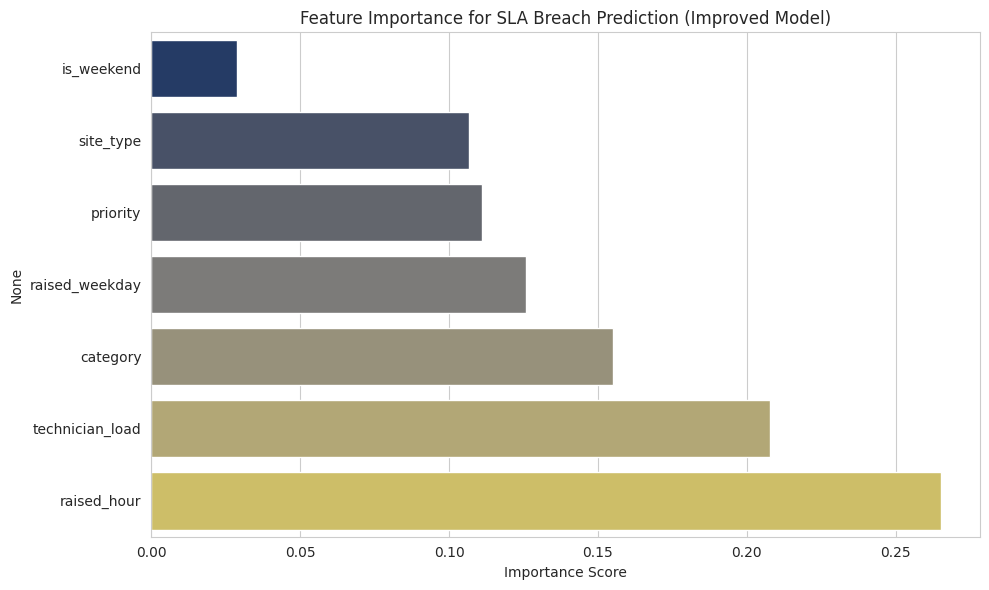

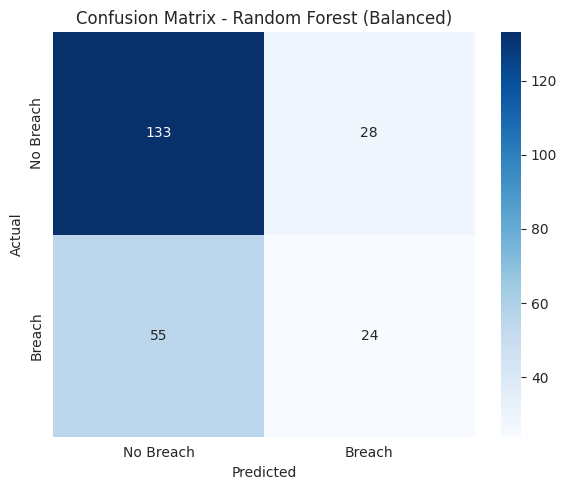

STEP 4 IMPROVED: Models retrained with class balancing and richer features.


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ==== STEP 4 (IMPROVED): HANDLE CLASS IMBALANCE + BETTER FEATURES ====

# Initialize model_df from df_clean
model_df = df_clean.copy()

# Add a technician workload feature (busier technicians may cause more breaches)
tech_load = model_df.groupby('assigned_technician')['ticket_id'].transform('count')
model_df['technician_load'] = tech_load

# Add weekend flag
model_df['is_weekend'] = model_df['raised_weekday'].isin(['Saturday', 'Sunday']).astype(int)

# Create the target variable 'sla_breach'
model_df['sla_breach'] = (model_df['sla_met'] == 'No').astype(int)

features = ['site_type', 'category', 'priority', 'raised_weekday', 'raised_hour', 'technician_load', 'is_weekend']
model_data = model_df[features + ['sla_breach']].copy()

le_dict = {}
for col in ['site_type', 'category', 'priority', 'raised_weekday']:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col])
    le_dict[col] = le

X = model_data[features]
y = model_data['sla_breach']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---- Logistic Regression with class_weight balanced ----
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("=" * 60)
print("LOGISTIC REGRESSION (BALANCED) RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, log_pred):.3f}")
print(f"Precision: {precision_score(y_test, log_pred):.3f}")
print(f"Recall: {recall_score(y_test, log_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, log_pred):.3f}")
print()
print(classification_report(y_test, log_pred, target_names=['No Breach', 'Breach'], zero_division=0))

# ---- Random Forest with class_weight balanced ----
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=" * 60)
print("RANDOM FOREST (BALANCED) RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall: {recall_score(y_test, rf_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.3f}")
print()
print(classification_report(y_test, rf_pred, target_names=['No Breach', 'Breach'], zero_division=0))

# ---- Feature Importance ----
plt.figure()
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette='cividis', legend=False)
plt.title('Feature Importance for SLA Breach Prediction (Improved Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150)
plt.show()

# ---- Confusion Matrix ----
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Breach', 'Breach'], yticklabels=['No Breach', 'Breach'])
plt.title('Confusion Matrix - Random Forest (Balanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png', dpi=150)
plt.show()

print("STEP 4 IMPROVED: Models retrained with class balancing and richer features.")

## Feature Importance

The Random Forest model reveals which factors most influence SLA breach risk — useful for identifying *where* to focus operational improvements, not just *how well* we can predict.

## Step 5: Threshold Tuning

The default 0.5 probability threshold under-detects real breaches (only 30% recall). This section tests multiple thresholds to find a better balance between catching more breaches (recall) and avoiding false alarms (precision).

THRESHOLD COMPARISON - RANDOM FOREST
Threshold   Accuracy    Precision   Recall      F1 Score    
----------------------------------------------------------------------
0.5         0.654       0.462       0.304       0.366       
0.4         0.608       0.424       0.532       0.472       
0.35        0.571       0.406       0.658       0.502       
0.3         0.508       0.377       0.759       0.504       
0.25        0.421       0.344       0.835       0.487       

FINAL MODEL AT THRESHOLD = 0.35
              precision    recall  f1-score   support

   No Breach       0.76      0.53      0.62       161
      Breach       0.41      0.66      0.50        79

    accuracy                           0.57       240
   macro avg       0.58      0.59      0.56       240
weighted avg       0.64      0.57      0.58       240



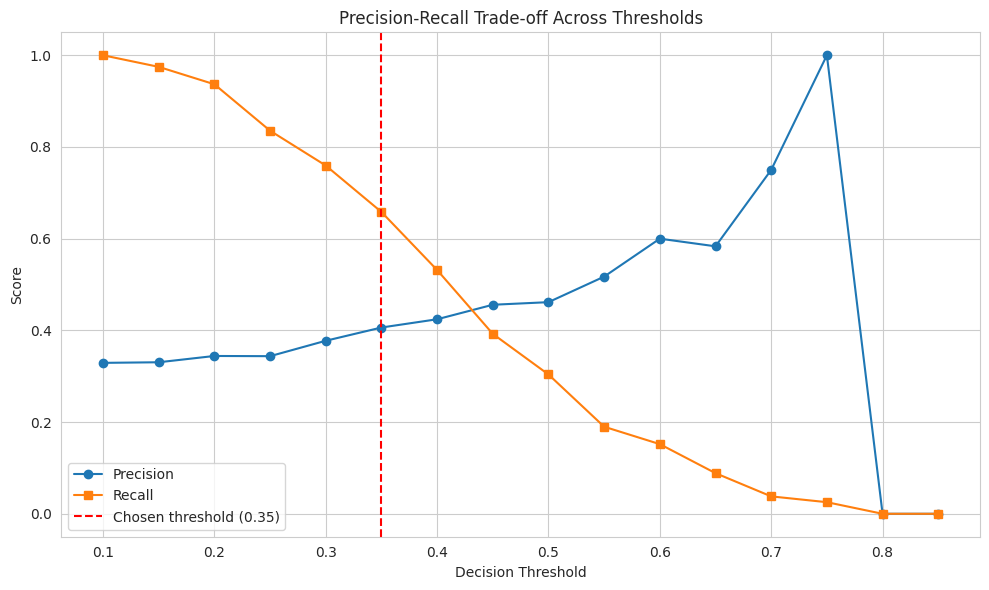

STEP 5 DONE: Threshold tuning complete.


In [3]:
# ==== STEP 5: THRESHOLD TUNING FOR BETTER RECALL ====

# Get predicted probabilities instead of hard predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]  # probability of "Breach"

# Try a few different thresholds and compare
thresholds = [0.5, 0.4, 0.35, 0.3, 0.25]

print("=" * 70)
print("THRESHOLD COMPARISON - RANDOM FOREST")
print("=" * 70)
print(f"{'Threshold':<12}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1 Score':<12}")
print("-" * 70)

for t in thresholds:
    preds_at_t = (rf_probs >= t).astype(int)
    acc = accuracy_score(y_test, preds_at_t)
    prec = precision_score(y_test, preds_at_t, zero_division=0)
    rec = recall_score(y_test, preds_at_t, zero_division=0)
    f1 = f1_score(y_test, preds_at_t, zero_division=0)
    print(f"{t:<12}{acc:<12.3f}{prec:<12.3f}{rec:<12.3f}{f1:<12.3f}")

print()

# Pick a chosen threshold (0.35 favors catching more breaches, a fair balance)
chosen_threshold = 0.35
final_preds = (rf_probs >= chosen_threshold).astype(int)

print("=" * 70)
print(f"FINAL MODEL AT THRESHOLD = {chosen_threshold}")
print("=" * 70)
print(classification_report(y_test, final_preds, target_names=['No Breach', 'Breach'], zero_division=0))

# Visualize the trade-off
plt.figure()
prec_list, rec_list = [], []
for t in np.arange(0.1, 0.9, 0.05):
    p = precision_score(y_test, (rf_probs >= t).astype(int), zero_division=0)
    r = recall_score(y_test, (rf_probs >= t).astype(int), zero_division=0)
    prec_list.append(p)
    rec_list.append(r)

plt.plot(np.arange(0.1, 0.9, 0.05), prec_list, marker='o', label='Precision')
plt.plot(np.arange(0.1, 0.9, 0.05), rec_list, marker='s', label='Recall')
plt.axvline(chosen_threshold, color='red', linestyle='--', label=f'Chosen threshold ({chosen_threshold})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('chart10_threshold_tradeoff.png', dpi=150)
plt.show()

print("STEP 5 DONE: Threshold tuning complete.")

## Key Findings

- Overall SLA compliance is ~67%, with a meaningful gap between average (35 hrs) and median (13 hrs) resolution time — a small number of outlier tickets are dragging performance down.
- **Time of day and technician workload** are stronger predictors of SLA breach than ticket category or priority — suggesting staffing and shift scheduling matter more than triage policy.
- At a tuned decision threshold (0.35), the model catches 66% of real breaches, compared to 30% at the default threshold — demonstrating the value of adjusting models to business priorities rather than using defaults blindly.
- These findings point toward proactive staffing adjustments during high-risk hours as a more effective lever than reactive ticket prioritization alone.